### Worked example on admission data

#### 0. Read spreadsheets
Let us start with a brand new R session. Download the data file(s) onto your working directory. To see your current working directory, type <code>getwd()</code> in R. To change it, use <code>setwd()</code> with your intended path inside the brackets. You can also click Files->Change dir in base R. 

We then use <code>read.csv()</code> to read in a csv spreadsheet, or <code>read.table()</code> for text-only (e.g. tab-separated) tables. 

First to import is the discharge spreadsheet. After loading it into R, it is no longer a csv file but an R object. An object is created, a name given, as indicated by the arrow. The first line of code reads as "I am importing Discharge.csv into my current R session, and I call it Discharge hereafter. ". 

With the discharge data imported I can look up its column (variable) names, number of rows, etc. There are built-in functions for most operations. 

In [1]:
# READ DISCHARGE SPREADSHEET
Discharge<-read.csv('Discharge.csv', header=T)
# DISPLAY VARIABLE NAMES
names(Discharge)
# DISPLAY DIMENSION OF THE DATA
dim(Discharge)
# SHOW THE FIRST FEW ROWS (HEAD) OF THE DATA
head(Discharge)

[1] "Discharge.Ward"         "Admission.Date"         "Discharge.Date"        
[4] "Spell.LOS"              "Hospital.Number"        "Discharge.Spell.Number"

[1] 1807    6

,Discharge.Ward,Admission.Date,Discharge.Date,Spell.LOS,Hospital.Number,Discharge.Spell.Number
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,T1,May-24,May-24,3,10000001,S0000001
2,W2,Dec-25,Dec-25,5,10000013,S0000013
3,T8,Aug-25,Aug-25,15,10000015,S0000017
4,W5,Jul-25,Jul-25,0,10000017,S0000018
5,W5,Dec-24,Dec-24,0,10000018,S0000019
6,W4,May-24,May-24,4,10000053,S0000056


Remember square brackets are for subsetting. For example, if I want to extracat the first column, I use <code>Discharge[,1]</code>. Another way is to call the column by name, like <code>Discharge$Discharge.Ward</code> with the dollar sign. 

Similarly, we can extract the first row by calling <code>Discharge[1,]</code>, and the first and third row together by <code>Discharge[c(1,3),]</code>. Since a data frame like this contains both rows and columns (2-dimensional), we have two indices inside the square brackets, i.e. <code>[row_id, column_id]</code>), separated by a comma. 

#### 1. Data pre-processing
Data pre-processing may include a collection of operations such as data cleansing, merging, recoding/reordering etc. In this example, we would like to import the admission data alongside discharge, then merge the two by a "key". Next we will remove columns that are redundant, and recode disease into two major types. 

Below illustrates a typical workflow of data pre-processing. Note that there are always multiple ways to tackle the same problem - but some are more elegant :-)

##### 1.1 Merge Discharge Ward into Admission
Import Admission.csv to the same R session. Now we would like to add an additional column to it to indicate <code>Discharge.Ward</code>, a variable available only from anoter dataset. Such procedure is called merging, and the function in R is <code>merge()</code>. There are several considerations: 1) The "key" is <code>Spell.Number</code> from admission data, which corresponds to <code>Discharge.Spell.Number</code> in discharge data), 2) we only need <code>Discharge.Ward</code> from dischage data, and 3) that we want to remove records (rows) with no match. 

Every functions in R comes with its help page by calling "?" before the function name. For instance, <code>?merge</code> will guide you to its manual. 

In [2]:
# SIMILARLY READ ADMISSION SPREADSHEET
Admission<-read.csv('Admission.csv', header=T)
# DISPLAY VARIABLE NAMES
names(Admission)
# DISPLAY DIMENSION OF THE DATA
dim(Admission)
# SHOW THE FIRST FEW ROWS (HEAD) OF THE DATA
head(Admission)

[1] "Division"          "Admission.Ward"    "Admission.Date"   
[4] "Discharged.Date"   "Spell.LOS"         "Primary.Diagnosis"
[7] "Post.Code"         "Hospital.Number"   "Spell.Number"

[1] 1610    9

,Division,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Spell.Number
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,Surgery and Cancer,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,S0002909
2,Surgery and Cancer,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,S0001112
3,Surgery and Cancer,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,S0002945
4,Surgery and Cancer,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,S0001111
5,Surgery and Cancer,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,S0001110
6,Surgery and Cancer,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,S0001109


In [3]:
# MERGE Discharge.Ward TO ADMISSION DATA
# by.x= AND by.y ARE THE COLUMN NAMES OF THE KEYS FOR MERGING THE TWO DATASETS
# all.x=FALSE TO REMOVE ROWS WITH NO MATCH
# NOTE THAT I ONLY NEED TO FIRST AND SIXTH COLUMN FROM Discharge
Admission_with_Discharge<-merge(Admission, Discharge[,c(1,6)], 
                                by.x='Spell.Number', by.y='Discharge.Spell.Number', 
                                all.x=FALSE, sort=FALSE)
dim(Admission_with_Discharge)
head(Admission_with_Discharge)

[1] 1606   10

,Spell.Number,Division,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,S0002909,Surgery and Cancer,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1
2,S0001112,Surgery and Cancer,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2
3,S0002945,Surgery and Cancer,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1
4,S0001111,Surgery and Cancer,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2
5,S0001110,Surgery and Cancer,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2
6,S0001109,Surgery and Cancer,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2


After merging <code>Discharge.Ward</code> into admission data, there are 1606 records retained. I save the results to a new R object (hence new object name). 

##### 1.2 Remove column(s)
For some reason I am not interested in <code>Division</code>. Again we use square brackets for subsetting, but this time with a minus sign to remove columns (or rows). Note that Division is the second column in this newly created data frame. 

In [4]:
# REMOVE COLUMN "Division", THE SECOND COLUMN
# REPLACE BY ITS OWN
Admission_with_Discharge<-Admission_with_Discharge[,-2]
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2


<code>Division</code> is gone! Now the data frame has 9 columns instead of 10. 

#### 1.3 Recode Diagnosis
The objective here is to recode disease into one of the two types: Sickle-cell and Thalassaemia, which can be inferred from the first four characters of <code>Primary.Diagnosis</code>. 

Therefore, it is a two-step process: first is to extract those four characters, then create a new variable, <code>Disease</code>, with the following definition: 
D570,D571,D572,D578=Sickle Cell
D561,D569=Thalassaemia

To extract the first four characters from <code>Primary.Diagnosis</code>, we use the substring operator <code>substr()</code>.  Then, I look at the disease code and decide which group it belongs to. The "belongs to" operator in R is <code>%in%</code> which return a boolean vector (of Trues and Falses). For instance: 

In [5]:
# CREATE A EMPTY COLUMN CALLED Disease WITHIN THE DATASET
Admission_with_Discharge$Disease<-NA

# EXTRACT THE FIRST FOUR CHARACTERS FROM Primary.Diagnosis, AND SAVE IT AS AN R OBJECT OUTSIDE OF THE DATASET
x<-substr(Admission_with_Discharge$Primary.Diagnosis, 1, 4)
head(x)

[1] "D570" "D570" "D570" "D570" "D570" "D570"

In [6]:
# IF x BELONGS TO D570, D571, D572, D578, THEY ARE SICKLE-CELL
Admission_with_Discharge$Disease[x %in% c('D570', 'D571', 'D572', 'D578')]<-'Sickle-cell'
Admission_with_Discharge$Disease[x %in% c('D561', 'D569')]<-'Thalassaemia'
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward,Disease
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1,Sickle-cell
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2,Sickle-cell
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1,Sickle-cell
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2,Sickle-cell
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2,Sickle-cell
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2,Sickle-cell


Note that the variable <code>x</code> is defined outside of the data frame and is no-longer required (but it is still there!). R has a whole suite of functions for "regular expression" which allows you to perform text editing or mining given a certain pattern of text. 

### 2. Data analysis
#### 2.1 Descriptive statistics
Once the dataset is neat and tidy we can start analysing it by running some descriptive statistics. For example, the count under each category, mean/median/sd for continuous variables, etc. <code>table()</code> and <code>summary()</code> are particularly useful here. 

In [7]:
# ADMISSION WARD. CATEGORICAL
table(Admission_with_Discharge$Admission.Ward)


  W1 
1606 

In [8]:
# DISCHARGE WARD. CATEGORICAL
table(Admission_with_Discharge$Discharge.Ward)


T12 T17  W1  W2  W3  W4  W6 
  4   1 852 697  42   2   8 

In [9]:
# BASIC SUMMARY OF Spell.LOS. Spell.LOS ARE DAYS
summary(Admission_with_Discharge$Spell.LOS)
# OR CUSTOM QUANTILES, SAY 5% AND 95%
quantile(Admission_with_Discharge$Spell.LOS, c(0.05, 0.95))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   1.000   3.849   6.000  70.000 

5% 95% 
  0  15

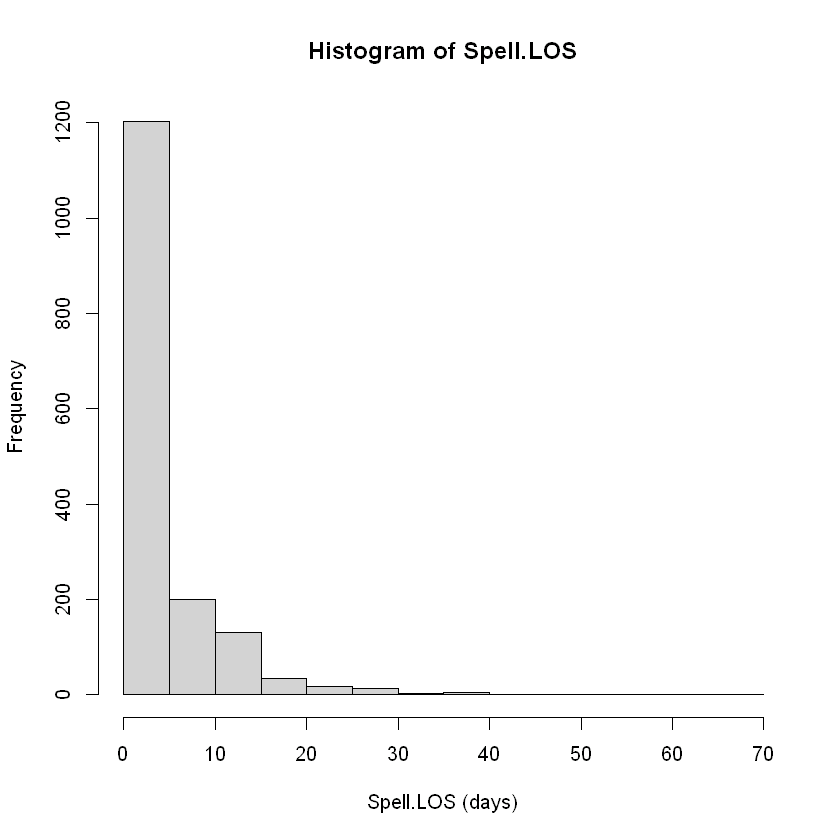

In [10]:
# HISTOGRAM, MORE ON PLOTS LATER
hist(Admission_with_Discharge$Spell.LOS, 
     main='Histogram of Spell.LOS', xlab='Spell.LOS (days)')

In [11]:
# Disease BY TYPE, CATEGORICAL
table(Admission_with_Discharge$Disease)


 Sickle-cell Thalassaemia 
        1601            5 

In [12]:
# CROSS TABULATION
table(Admission_with_Discharge$Disease, Admission_with_Discharge$Discharge.Ward)

              
               T12 T17  W1  W2  W3  W4  W6
  Sickle-cell    4   1 847 697  42   2   8
  Thalassaemia   0   0   5   0   0   0   0

The examples above demonstrated how easy summary tables are created for reporting. Further, cross tabulation allows us to visualise any association between two categorical variables. 

#### 2.2 Play around with dates
We have two dates in this dataset: <code>Admission.Date</code> and <code>Discharged.Date</code>, currently recognised as characters in R. R supports POSIX date format for date operations (e.g. count the number of days between two dates, work out the week of the day, etc), but I am not going to discussed here. Interested reader should consult <code>as.Date</code> for R's <code>Date</code> object type. 

A simpler alternative is to split our date variable into two as month and year, using <code>substr()</code> again. Below is my implementation to create four new variables associated with dates: 

In [13]:
# RECODE Date INTO Month AND Year IN TWO SEPARATE VARIABLES
# FIRST TWO CHARACTERS ARE MM, CHARACTERS 4-7 ARE YYYY. THEN CONVERT INTO NUMERIC
# Admission
Admission_with_Discharge$Admission.Month<-as.numeric(substr(Admission_with_Discharge$Admission.Date, 1, 2))
Admission_with_Discharge$Admission.Year<-as.numeric(substr(Admission_with_Discharge$Admission.Date, 4, 7))
# DO THE SAME FOR Discharged
Admission_with_Discharge$Discharged.Month<-as.numeric(substr(Admission_with_Discharge$Discharged.Date, 1, 2))
Admission_with_Discharge$Discharged.Year<-as.numeric(substr(Admission_with_Discharge$Discharged.Date, 4, 7))

You may view the data frame again but I'm confident enough that they are done properly. <code>as.numeric</code> is to turn characters into numbers. Note that <code>0</code> is a number, but <code>'0'</code> with a quote is a character. 

#### 2.3 More on dates. Financial year. 
Financial year is of some interest when money is involved. It can be inferred from <code>Admission.Year</code> and <code>Admission.Month</code> we just created, and if it belongs to the first three months we assign it to the previous financial year. A logical statement is needed here, and my choice is <code>ifelse</code>: 

In [19]:
# ADMISSION FINANCIAL YEAR?
Admission_with_Discharge$Financial.Year<-ifelse(Admission_with_Discharge$Admission.Month<=3, 
                                                Admission_with_Discharge$Admission.Year-1, 
                                                Admission_with_Discharge$Admission.Year)
# FIVE ADDITIONAL VARIABLES ON DATES ARE CREATED 
head(Admission_with_Discharge)

,Spell.Number,Admission.Ward,Admission.Date,Discharged.Date,Spell.LOS,Primary.Diagnosis,Post.Code,Hospital.Number,Discharge.Ward,Disease,Admission.Month,Admission.Year,Discharged.Month,Discharged.Year,Financial.Year
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,S0002909,W1,08/2025,08/2025,0,D570 - Sickle-cell anaemia with crisis,HA0,10000155,W1,Sickle-cell,8,2025,8,2025,2025
2,S0001112,W1,01/2026,02/2026,4,D570 - Sickle-cell anaemia with crisis,NW10,10000209,W2,Sickle-cell,1,2026,2,2026,2025
3,S0002945,W1,01/2026,01/2026,0,D570 - Sickle-cell anaemia with crisis,TW8,10000010,W1,Sickle-cell,1,2026,1,2026,2025
4,S0001111,W1,01/2026,01/2026,2,D570 - Sickle-cell anaemia with crisis,NW10,10000182,W2,Sickle-cell,1,2026,1,2026,2025
5,S0001110,W1,01/2026,01/2026,4,D570 - Sickle-cell anaemia with crisis,W10,10000448,W2,Sickle-cell,1,2026,1,2026,2025
6,S0001109,W1,01/2026,02/2026,10,D570 - Sickle-cell anaemia with crisis,HA9,10000184,W2,Sickle-cell,1,2026,2,2026,2025


In [15]:
# NUMBER OF DISCHARGED PATIENTS PER MONTH
by(Admission_with_Discharge, Admission_with_Discharge$Discharged.Month, nrow)

Admission_with_Discharge$Discharged.Month: 1
[1] 151
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 2
[1] 59
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 3
[1] 62
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 4
[1] 114
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 5
[1] 139
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 6
[1] 152
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 7
[1] 147
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 8
[1] 148
------------------------------------------------------------ 
Admission_with_Discharge$Discharged.Month: 9
[1] 155
-----------------------------

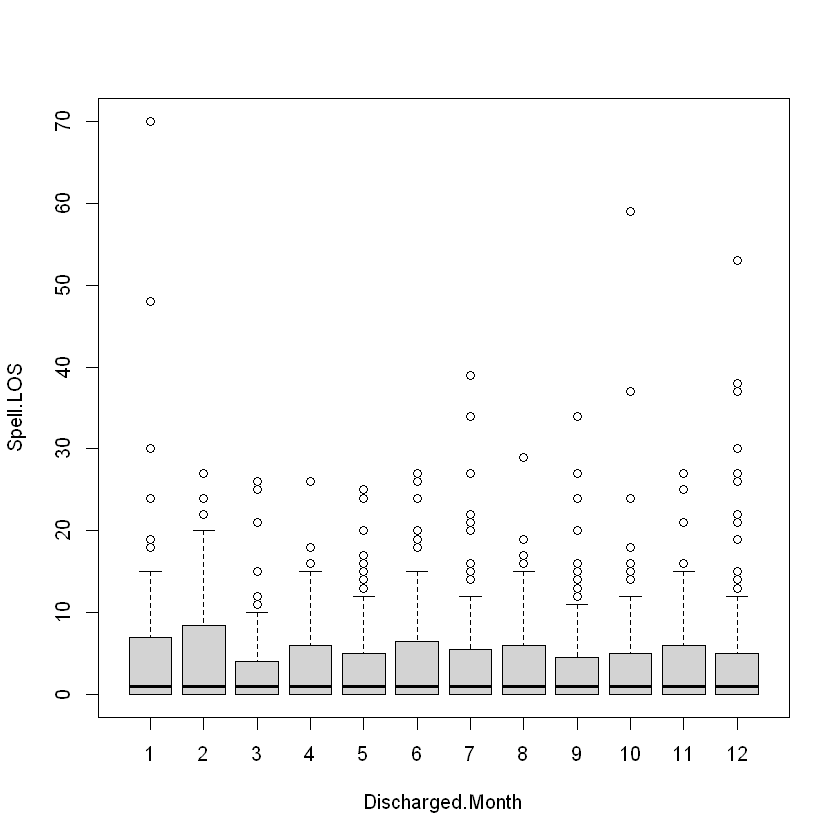

In [16]:
boxplot(Spell.LOS~Discharged.Month, data=Admission_with_Discharge)

In [17]:
# LIST OF PATENTS WITH LOS>=21 DAYS
y<-Admission_with_Discharge[Admission_with_Discharge$Spell.LOS>=21,]
by(y, y$Financial.Year, nrow)

y$Financial.Year: 0
[1] 5
------------------------------------------------------------ 
y$Financial.Year: 1
[1] 3
------------------------------------------------------------ 
y$Financial.Year: 2
[1] 1
------------------------------------------------------------ 
y$Financial.Year: 4
[1] 2
------------------------------------------------------------ 
y$Financial.Year: 5
[1] 4
------------------------------------------------------------ 
y$Financial.Year: 6
[1] 4
------------------------------------------------------------ 
y$Financial.Year: 7
[1] 2
------------------------------------------------------------ 
y$Financial.Year: 8
[1] 3
------------------------------------------------------------ 
y$Financial.Year: 9
[1] 3
------------------------------------------------------------ 
y$Financial.Year: 10
[1] 5
------------------------------------------------------------ 
y$Financial.Year: 11
[1] 8

In [18]:
# TOTAL BED TIME FROM THESE LOS>=21 DAYS 
by(y$Spell.LOS, y$Financial.Year, sum)

y$Financial.Year: 0
[1] 127
------------------------------------------------------------ 
y$Financial.Year: 1
[1] 72
------------------------------------------------------------ 
y$Financial.Year: 2
[1] 26
------------------------------------------------------------ 
y$Financial.Year: 4
[1] 49
------------------------------------------------------------ 
y$Financial.Year: 5
[1] 101
------------------------------------------------------------ 
y$Financial.Year: 6
[1] 116
------------------------------------------------------------ 
y$Financial.Year: 7
[1] 56
------------------------------------------------------------ 
y$Financial.Year: 8
[1] 85
------------------------------------------------------------ 
y$Financial.Year: 9
[1] 120
------------------------------------------------------------ 
y$Financial.Year: 10
[1] 163
------------------------------------------------------------ 
y$Financial.Year: 11
[1] 282